<a href="https://colab.research.google.com/github/baanujan-18/PLC---Automation/blob/main/plc-metal-sorting-conveyor-system/colab/PLC_metal_sorting_conveyor_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

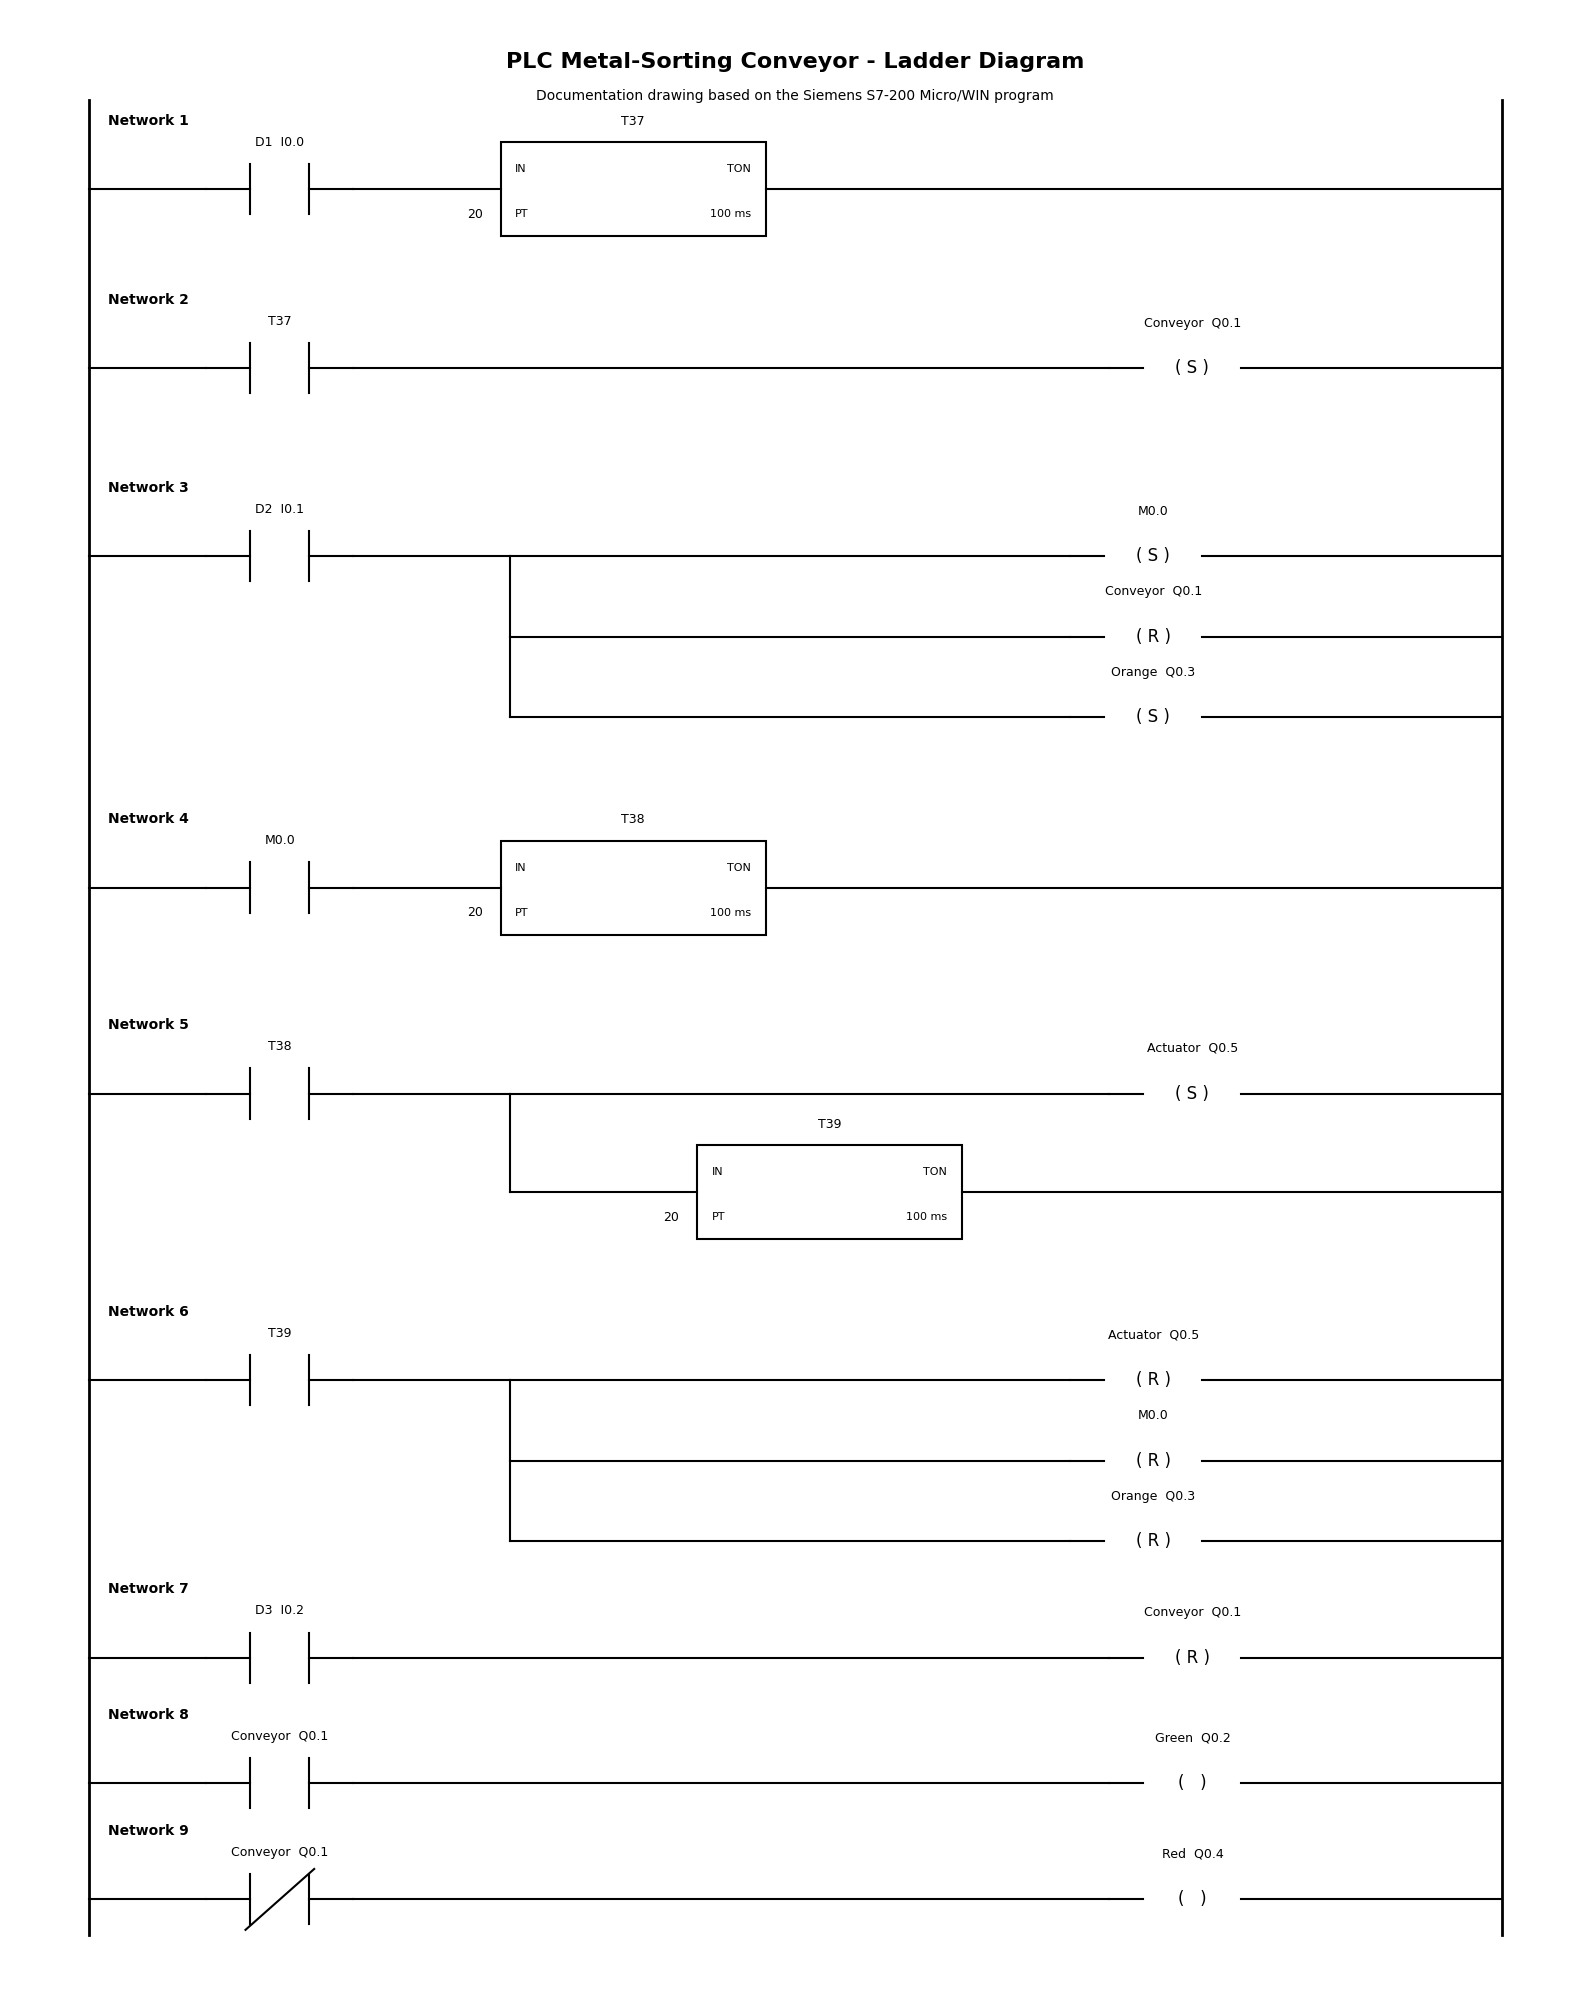

Files created:
metal_sorting_ladder_exact.png
metal_sorting_ladder_exact.pdf


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Figure setup
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 20))

ax.set_xlim(0, 16)
ax.set_ylim(0, 22)
ax.axis("off")

LEFT_RAIL = 0.8
RIGHT_RAIL = 15.2
LINE_COLOR = "black"

# Main ladder rails
ax.plot(
    [LEFT_RAIL, LEFT_RAIL],
    [0.5, 21.0],
    linewidth=2,
    color=LINE_COLOR
)

ax.plot(
    [RIGHT_RAIL, RIGHT_RAIL],
    [0.5, 21.0],
    linewidth=2,
    color=LINE_COLOR
)


# ---------------------------------------------------------
# Drawing functions
# ---------------------------------------------------------

def wire(x1, x2, y, linewidth=1.5):
    """Draw a horizontal ladder wire."""
    ax.plot(
        [x1, x2],
        [y, y],
        linewidth=linewidth,
        color=LINE_COLOR
    )


def vertical_wire(x, y1, y2, linewidth=1.5):
    """Draw a vertical branch wire."""
    ax.plot(
        [x, x],
        [y1, y2],
        linewidth=linewidth,
        color=LINE_COLOR
    )


def contact(x, y, label, normally_closed=False):
    """
    Draw a normally open or normally closed contact.
    Returns the x-coordinate at the end of the contact.
    """

    wire(x, x + 0.45, y)

    ax.plot(
        [x + 0.45, x + 0.45],
        [y - 0.28, y + 0.28],
        linewidth=1.5,
        color=LINE_COLOR
    )

    ax.plot(
        [x + 1.05, x + 1.05],
        [y - 0.28, y + 0.28],
        linewidth=1.5,
        color=LINE_COLOR
    )

    if normally_closed:
        ax.plot(
            [x + 0.40, x + 1.10],
            [y - 0.34, y + 0.34],
            linewidth=1.5,
            color=LINE_COLOR
        )

    wire(x + 1.05, x + 1.5, y)

    ax.text(
        x + 0.75,
        y + 0.45,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

    return x + 1.5


def coil(x, y, label, coil_type=""):
    """
    Draw a standard, SET, or RESET coil.

    coil_type:
    ""  = standard coil
    "S" = set coil
    "R" = reset coil
    """

    wire(x, x + 0.35, y)

    if coil_type:
        symbol = f"( {coil_type} )"
    else:
        symbol = "(   )"

    ax.text(
        x + 0.85,
        y,
        symbol,
        ha="center",
        va="center",
        fontsize=12
    )

    ax.text(
        x + 0.85,
        y + 0.43,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

    wire(x + 1.35, RIGHT_RAIL, y)


def ton_timer(x, y, timer_name, preset=20, time_base="100 ms"):
    """
    Draw a Siemens-style TON timer block.
    """

    width = 2.7
    height = 1.05

    timer_box = Rectangle(
        (x, y - height / 2),
        width,
        height,
        fill=False,
        linewidth=1.5,
        edgecolor=LINE_COLOR
    )

    ax.add_patch(timer_box)

    ax.text(
        x + 0.15,
        y + 0.22,
        "IN",
        fontsize=8,
        ha="left",
        va="center"
    )

    ax.text(
        x + width - 0.15,
        y + 0.22,
        "TON",
        fontsize=8,
        ha="right",
        va="center"
    )

    ax.text(
        x + 0.15,
        y - 0.28,
        "PT",
        fontsize=8,
        ha="left",
        va="center"
    )

    ax.text(
        x + width - 0.15,
        y - 0.28,
        time_base,
        fontsize=8,
        ha="right",
        va="center"
    )

    ax.text(
        x + width / 2,
        y + 0.72,
        timer_name,
        fontsize=9,
        ha="center"
    )

    ax.text(
        x - 0.18,
        y - 0.28,
        str(preset),
        fontsize=9,
        ha="right",
        va="center"
    )

    return x + width


def network_label(number, y):
    ax.text(
        1.0,
        y + 0.72,
        f"Network {number}",
        fontsize=10,
        fontweight="bold",
        ha="left"
    )


# ---------------------------------------------------------
# Network 1
# D1 I0.0 -> TON T37
# Preset: 20 x 100 ms = 2 seconds
# ---------------------------------------------------------

y = 20.0

network_label(1, y)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "D1  I0.0"
)

wire(end_contact, 5.0, y)

end_timer = ton_timer(
    5.0,
    y,
    "T37",
    preset=20,
    time_base="100 ms"
)

wire(end_timer, RIGHT_RAIL, y)


# ---------------------------------------------------------
# Network 2
# T37 -> SET Conveyor Q0.1
# ---------------------------------------------------------

y = 18.0

network_label(2, y)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "T37"
)

wire(end_contact, 11.2, y)

coil(
    11.2,
    y,
    "Conveyor  Q0.1",
    "S"
)


# ---------------------------------------------------------
# Network 3
# D2 I0.1:
# - SET M0.0
# - RESET Conveyor Q0.1
# - SET Orange Q0.3
# ---------------------------------------------------------

top_y = 15.9

network_label(3, top_y)

wire(LEFT_RAIL, 2.0, top_y)

end_contact = contact(
    2.0,
    top_y,
    "D2  I0.1"
)

branch_x = 5.1

wire(end_contact, branch_x, top_y)

vertical_wire(
    branch_x,
    14.1,
    top_y
)

# Branch 1: Set M0.0
wire(branch_x, 10.8, 15.9)

coil(
    10.8,
    15.9,
    "M0.0",
    "S"
)

# Branch 2: Reset conveyor
wire(branch_x, 10.8, 15.0)

coil(
    10.8,
    15.0,
    "Conveyor  Q0.1",
    "R"
)

# Branch 3: Set orange lamp
wire(branch_x, 10.8, 14.1)

coil(
    10.8,
    14.1,
    "Orange  Q0.3",
    "S"
)


# ---------------------------------------------------------
# Network 4
# M0.0 -> TON T38
# Preset: 20 x 100 ms = 2 seconds
# ---------------------------------------------------------

y = 12.2

network_label(4, y)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "M0.0"
)

wire(end_contact, 5.0, y)

end_timer = ton_timer(
    5.0,
    y,
    "T38",
    preset=20,
    time_base="100 ms"
)

wire(end_timer, RIGHT_RAIL, y)


# ---------------------------------------------------------
# Network 5
# T38:
# - SET Actuator Q0.5
# - Start TON T39 in parallel
# ---------------------------------------------------------

top_y = 9.9

network_label(5, top_y)

wire(LEFT_RAIL, 2.0, top_y)

end_contact = contact(
    2.0,
    top_y,
    "T38"
)

branch_x = 5.1

wire(end_contact, branch_x, top_y)

vertical_wire(
    branch_x,
    8.8,
    top_y
)

# Top branch: Set actuator
wire(branch_x, 11.2, top_y)

coil(
    11.2,
    top_y,
    "Actuator  Q0.5",
    "S"
)

# Bottom branch: Start T39
wire(branch_x, 7.0, 8.8)

end_timer = ton_timer(
    7.0,
    8.8,
    "T39",
    preset=20,
    time_base="100 ms"
)

wire(end_timer, RIGHT_RAIL, 8.8)


# ---------------------------------------------------------
# Network 6
# T39:
# - RESET Actuator Q0.5
# - RESET M0.0
# - RESET Orange Q0.3
# ---------------------------------------------------------

top_y = 6.7

network_label(6, top_y)

wire(LEFT_RAIL, 2.0, top_y)

end_contact = contact(
    2.0,
    top_y,
    "T39"
)

branch_x = 5.1

wire(end_contact, branch_x, top_y)

vertical_wire(
    branch_x,
    4.9,
    top_y
)

# Branch 1: Reset actuator
wire(branch_x, 10.8, 6.7)

coil(
    10.8,
    6.7,
    "Actuator  Q0.5",
    "R"
)

# Branch 2: Reset memory bit
wire(branch_x, 10.8, 5.8)

coil(
    10.8,
    5.8,
    "M0.0",
    "R"
)

# Branch 3: Reset orange indicator
wire(branch_x, 10.8, 4.9)

coil(
    10.8,
    4.9,
    "Orange  Q0.3",
    "R"
)


# ---------------------------------------------------------
# Network 7
# D3 I0.2 -> RESET Conveyor Q0.1
# ---------------------------------------------------------

y = 3.6

network_label(7, y)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "D3  I0.2"
)

wire(end_contact, 11.2, y)

coil(
    11.2,
    y,
    "Conveyor  Q0.1",
    "R"
)


# ---------------------------------------------------------
# Network 8
# Conveyor Q0.1 normally open -> Green Q0.2
# ---------------------------------------------------------

y = 2.2

network_label(8, y)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "Conveyor  Q0.1"
)

wire(end_contact, 11.2, y)

coil(
    11.2,
    y,
    "Green  Q0.2"
)


# ---------------------------------------------------------
# Network 9
# Conveyor Q0.1 normally closed -> Red Q0.4
# ---------------------------------------------------------

y = 0.9

network_label(9, y)

wire(LEFT_RAIL, 2.0, y)

end_contact = contact(
    2.0,
    y,
    "Conveyor  Q0.1",
    normally_closed=True
)

wire(end_contact, 11.2, y)

coil(
    11.2,
    y,
    "Red  Q0.4"
)


# ---------------------------------------------------------
# Title and export
# ---------------------------------------------------------

ax.text(
    8.0,
    21.35,
    "PLC Metal-Sorting Conveyor - Ladder Diagram",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    8.0,
    21.0,
    "Documentation drawing based on the Siemens S7-200 Micro/WIN program",
    ha="center",
    fontsize=10
)

plt.tight_layout()

# Save PNG for GitHub
plt.savefig(
    "metal_sorting_ladder_exact.png",
    dpi=300,
    bbox_inches="tight"
)

# Save PDF version
plt.savefig(
    "metal_sorting_ladder_exact.pdf",
    bbox_inches="tight"
)

plt.show()

print("Files created:")
print("metal_sorting_ladder_exact.png")
print("metal_sorting_ladder_exact.pdf")

In [ ]:
from google.colab import files

files.download("metal_sorting_ladder_exact.png")
files.download("metal_sorting_ladder_exact.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>